# 💼 LinkedIn Salary Predictor + Skill Value Analysis

**Датасет:** arshkon/linkedin-job-postings (2023–2024) · 124k вакансий · 11 файлов

**Три задачи:**
1. 🎯 **Регрессия** — предсказать годовую зарплату (`annual_salary`)
2. 🏷️ **Мультикласс** — предсказать уровень опыта (`experience_level`)
3. ✅ **Бинарная** — высокооплачиваемая вакансия или нет (`is_high_salary`)

**Структура:**
- Часть 1: Загрузка и джойн 11 файлов
- Часть 2: EDA
- Часть 3: Feature Engineering + NLP
- Часть 4: Train / Validation / Predict split
- Часть 5: Модели (Модель А: числа | Модель Б: числа + TF-IDF)
- Часть 6: Skill Value Analysis
- Часть 7: Выводы

## 0. Установка и импорты

In [2]:
# !pip install pandas numpy matplotlib seaborn scikit-learn xgboost tqdm
! pip install seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                              accuracy_score, classification_report,
                              confusion_matrix, roc_auc_score)
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack

try:
    from xgboost import XGBRegressor, XGBClassifier
    XGBOOST = True
except ImportError:
    XGBOOST = False
    print('XGBoost не установлен')

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')
print('Библиотеки загружены')


[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


XGBoost не установлен
Библиотеки загружены


## 1. Загрузка и объединение файлов

### Структура датасета
```
postings.csv          — 124k вакансий, основной файл
companies.csv         — данные компаний (размер, отрасль, followers)
job_skills.csv        — навыки вакансии (один навык = одна строка)
benefits.csv          — льготы (Medical, 401k, Remote Work...)
job_industries.csv    — отрасли вакансии
industries.csv        — справочник отраслей (id → название)
salaries.csv          — детализированные зарплаты
```
Все файлы джойнятся по `job_id` или `company_id`.

In [3]:
# ── Укажи путь к папке с файлами ──
DATA_PATH = 'data/'   # папка куда скачал датасет

# ── 1. Основной файл ──
print('Загружаю postings.csv...')
df = pd.read_csv(DATA_PATH + 'postings.csv')
print(f'  postings: {df.shape}')
print(f'  Колонки: {df.columns.tolist()}')

Загружаю postings.csv...
  postings: (123849, 31)
  Колонки: ['job_id', 'company_name', 'title', 'description', 'max_salary', 'pay_period', 'location', 'company_id', 'views', 'med_salary', 'min_salary', 'formatted_work_type', 'applies', 'original_listed_time', 'remote_allowed', 'job_posting_url', 'application_url', 'application_type', 'expiry', 'closed_time', 'formatted_experience_level', 'skills_desc', 'listed_time', 'posting_domain', 'sponsored', 'work_type', 'currency', 'compensation_type', 'normalized_salary', 'zip_code', 'fips']


In [5]:
# ── 2. Компании ──
print('Загружаю companies.csv...')
df_companies = pd.read_csv(DATA_PATH + 'companies.csv')
print(f'  companies: {df_companies.shape}')
print(f'  Колонки: {df_companies.columns.tolist()}')

Загружаю companies.csv...
  companies: (24473, 10)
  Колонки: ['company_id', 'name', 'description', 'company_size', 'state', 'country', 'city', 'zip_code', 'address', 'url']


In [6]:
# ── 3. Навыки — агрегируем по job_id ──
print('Загружаю job_skills.csv...')
df_skills_raw = pd.read_csv(DATA_PATH + 'job_skills.csv')
print(f'  job_skills raw: {df_skills_raw.shape}')

# Агрегируем: для каждой вакансии — список навыков и их количество
df_skills = df_skills_raw.groupby('job_id').agg(
    skill_count=('skill_abr', 'count'),
    skills_list=('skill_abr', lambda x: ', '.join(x.unique()))
).reset_index()
print(f'  job_skills агрег: {df_skills.shape}')

Загружаю job_skills.csv...
  job_skills raw: (213768, 2)
  job_skills агрег: (126807, 3)


In [7]:
# ── 4. Льготы — агрегируем по job_id ──
print('Загружаю benefits.csv...')
df_benefits_raw = pd.read_csv(DATA_PATH + 'benefits.csv')
print(f'  benefits raw: {df_benefits_raw.shape}')
print(f'  Типы льгот: {df_benefits_raw["type"].value_counts().head(10).to_dict()}')

# Агрегируем: кол-во льгот + флаги ключевых льгот
df_benefits = df_benefits_raw.groupby('job_id').agg(
    benefit_count=('type', 'count'),
    has_medical=('type', lambda x: int('Medical insurance' in x.values)),
    has_dental=('type', lambda x: int('Dental insurance' in x.values)),
    has_401k=('type', lambda x: int('401(k)' in x.values)),
    has_remote_benefit=('type', lambda x: int('Work from home' in x.values)),
    has_student_loan=('type', lambda x: int('Student loan assistance' in x.values)),
).reset_index()
print(f'  benefits агрег: {df_benefits.shape}')

Загружаю benefits.csv...
  benefits raw: (67943, 3)
  Типы льгот: {'401(k)': 24231, 'Medical insurance': 9873, 'Vision insurance': 9309, 'Disability insurance': 7930, 'Dental insurance': 6868, 'Tuition assistance': 2614, 'Commuter benefits': 2226, 'Paid maternity leave': 1808, 'Paid paternity leave': 1540, 'Pension plan': 906}
  benefits агрег: (30023, 7)


In [8]:
# ── 5. Отрасли — агрегируем и джойним с названиями ──
print('Загружаю industries...')
df_job_industries = pd.read_csv(DATA_PATH + 'job_industries.csv')
df_industries_ref = pd.read_csv(DATA_PATH + 'industries.csv')

# Джойним с названиями
df_job_industries = df_job_industries.merge(
    df_industries_ref, on='industry_id', how='left')

# Агрегируем: главная отрасль + количество
df_industries = df_job_industries.groupby('job_id').agg(
    main_industry=('industry_name', 'first'),
    industry_count=('industry_name', 'count')
).reset_index()
print(f'  industries агрег: {df_industries.shape}')

Загружаю industries...
  industries агрег: (127125, 3)


In [9]:
# ── ГЛАВНЫЙ ДЖОЙН — собираем всё вместе ──
print('Джойним все файлы по job_id...')

df_full = df.copy()

# Джойн с компаниями по company_id
company_cols = ['company_id', 'company_size', 'employee_count',
                'follower_count', 'company_type']
company_cols = [c for c in company_cols if c in df_companies.columns]
df_full = df_full.merge(
    df_companies[company_cols],
    on='company_id', how='left'
)

# Джойн навыков
df_full = df_full.merge(df_skills, on='job_id', how='left')

# Джойн льгот
df_full = df_full.merge(df_benefits, on='job_id', how='left')

# Джойн отраслей
df_full = df_full.merge(df_industries, on='job_id', how='left')

print(f'Итоговый датасет: {df_full.shape[0]:,} строк x {df_full.shape[1]} колонок')
print(f'Колонки: {df_full.columns.tolist()}')

Джойним все файлы по job_id...
Итоговый датасет: 123,849 строк x 42 колонок
Колонки: ['job_id', 'company_name', 'title', 'description', 'max_salary', 'pay_period', 'location', 'company_id', 'views', 'med_salary', 'min_salary', 'formatted_work_type', 'applies', 'original_listed_time', 'remote_allowed', 'job_posting_url', 'application_url', 'application_type', 'expiry', 'closed_time', 'formatted_experience_level', 'skills_desc', 'listed_time', 'posting_domain', 'sponsored', 'work_type', 'currency', 'compensation_type', 'normalized_salary', 'zip_code', 'fips', 'company_size', 'skill_count', 'skills_list', 'benefit_count', 'has_medical', 'has_dental', 'has_401k', 'has_remote_benefit', 'has_student_loan', 'main_industry', 'industry_count']


In [10]:
df_full.head(3)

,job_id,company_name,title,description,max_salary,pay_period,location,company_id,views,med_salary,...,skill_count,skills_list,benefit_count,has_medical,has_dental,has_401k,has_remote_benefit,has_student_loan,main_industry,industry_count
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,Job descriptionA leading real estate firm in N...,20.0,HOURLY,"Princeton, NJ",2774458.0,20.0,NaN,...,2.0,"MRKT, SALE",NaN,NaN,NaN,NaN,NaN,NaN,Real Estate,1.0
1,1829192,NaN,Mental Health Therapist/Counselor,"At Aspen Therapy and Wellness , we are committ...",50.0,HOURLY,"Fort Collins, CO",NaN,1.0,NaN,...,1.0,HCPR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,10998357,The National Exemplar,Assitant Restaurant Manager,The National Exemplar is accepting application...,65000.0,YEARLY,"Cincinnati, OH",64896719.0,8.0,NaN,...,2.0,"MGMT, MNFC",NaN,NaN,NaN,NaN,NaN,NaN,Restaurants,1.0


## 2. Нормализация зарплат

Зарплаты хранятся в разных единицах: `HOURLY`, `MONTHLY`, `YEARLY`.
Приводим всё к **годовой зарплате в USD** перед любым анализом.

In [11]:
# Смотрим на распределение pay_period
print('pay_period:')
print(df_full['pay_period'].value_counts())
print()
print(f'Строк с зарплатой (med_salary): {df_full["med_salary"].notna().sum():,}')
print(f'Строк без зарплаты:             {df_full["med_salary"].isna().sum():,}')
print(f'% с зарплатой: {df_full["med_salary"].notna().mean()*100:.1f}%')

pay_period:
pay_period
YEARLY      20628
HOURLY      14741
MONTHLY       518
WEEKLY        177
BIWEEKLY        9
Name: count, dtype: int64

Строк с зарплатой (med_salary): 6,280
Строк без зарплаты:             117,569
% с зарплатой: 5.1%


In [12]:
# Нормализация к годовой зарплате
HOURS_PER_YEAR = 2080   # 40 часов * 52 недели
MONTHS_PER_YEAR = 12

def normalize_salary(row):
    salary = row.get('med_salary') or row.get('max_salary') or row.get('min_salary')
    period = str(row.get('pay_period', '')).upper()
    if pd.isna(salary):
        return np.nan
    if period == 'HOURLY':
        return salary * HOURS_PER_YEAR
    elif period == 'MONTHLY':
        return salary * MONTHS_PER_YEAR
    else:  # YEARLY или пусто
        return salary

df_full['annual_salary'] = df_full.apply(normalize_salary, axis=1)

# Фильтруем реалистичные зарплаты (убираем выбросы)
salary_mask = (df_full['annual_salary'] >= 15_000) & \
              (df_full['annual_salary'] <= 500_000)
df_with_salary = df_full[df_full['annual_salary'].notna() & salary_mask].copy()

print(f'Строк с реалистичной зарплатой: {len(df_with_salary):,}')
print(f'Диапазон: ${df_with_salary["annual_salary"].min():,.0f} — ${df_with_salary["annual_salary"].max():,.0f}')
print(f'Медиана: ${df_with_salary["annual_salary"].median():,.0f}')
print(f'Среднее: ${df_with_salary["annual_salary"].mean():,.0f}')

Строк с реалистичной зарплатой: 6,198
Диапазон: $15,000 — $500,000
Медиана: $47,840
Среднее: $64,103


## 3. EDA — Анализ данных

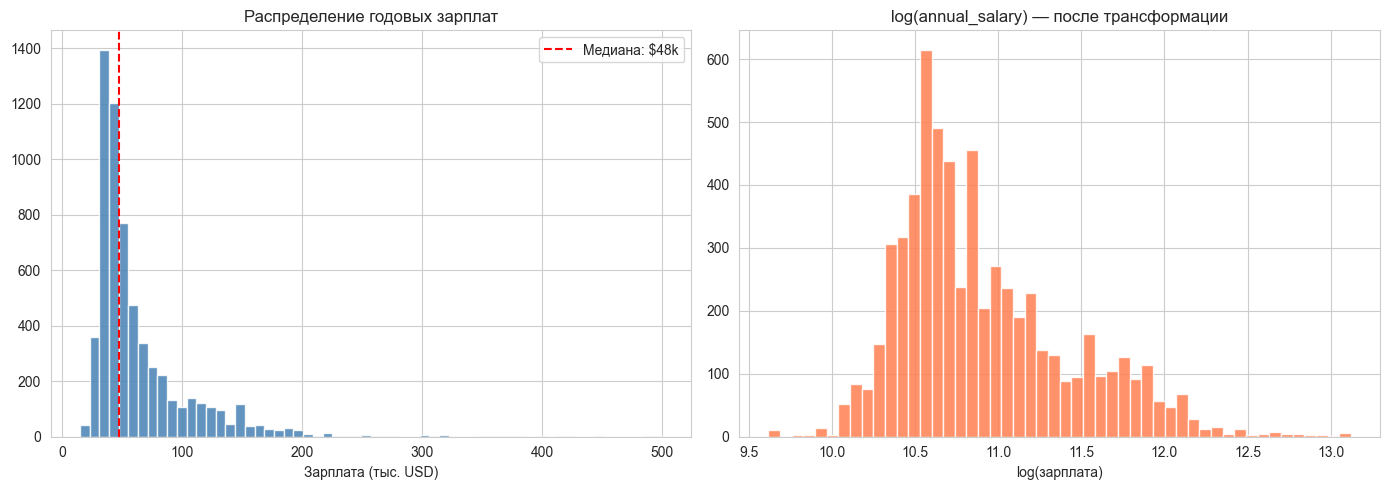

In [13]:
# Распределение зарплат
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_with_salary['annual_salary'] / 1000, bins=60,
             color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Распределение годовых зарплат')
axes[0].set_xlabel('Зарплата (тыс. USD)')
axes[0].axvline(df_with_salary['annual_salary'].median() / 1000,
                color='red', linestyle='--',
                label=f'Медиана: ${df_with_salary["annual_salary"].median()/1000:.0f}k')
axes[0].legend()

axes[1].hist(np.log(df_with_salary['annual_salary']), bins=50,
             color='coral', edgecolor='white', alpha=0.85)
axes[1].set_title('log(annual_salary) — после трансформации')
axes[1].set_xlabel('log(зарплата)')

plt.tight_layout()
plt.show()

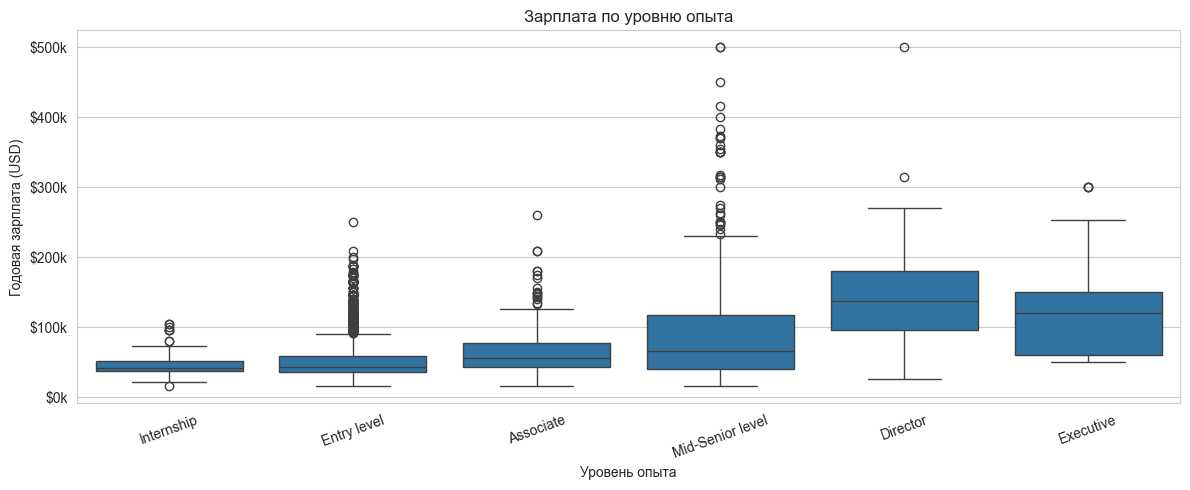

In [14]:
# Зарплата по уровню опыта
if 'formatted_experience_level' in df_with_salary.columns:
    exp_order = ['Internship', 'Entry level', 'Associate',
                 'Mid-Senior level', 'Director', 'Executive']
    exp_order = [e for e in exp_order
                 if e in df_with_salary['formatted_experience_level'].unique()]

    fig, ax = plt.subplots(figsize=(12, 5))
    sns.boxplot(data=df_with_salary,
                x='formatted_experience_level',
                y='annual_salary',
                order=exp_order, ax=ax)
    ax.set_title('Зарплата по уровню опыта')
    ax.set_xlabel('Уровень опыта')
    ax.set_ylabel('Годовая зарплата (USD)')
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}k'))
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

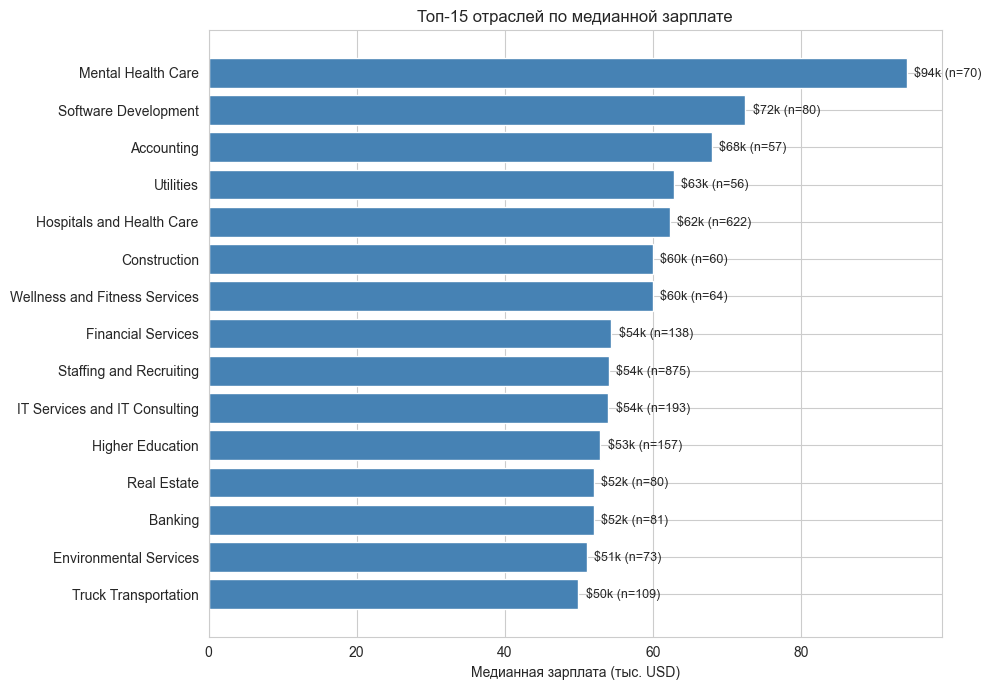

In [15]:
# Топ-15 отраслей по медианной зарплате
if 'main_industry' in df_with_salary.columns:
    industry_salary = df_with_salary.groupby('main_industry')['annual_salary']\
        .agg(['median', 'count']).reset_index()
    industry_salary = industry_salary[industry_salary['count'] >= 50]\
        .sort_values('median', ascending=True).tail(15)

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.barh(industry_salary['main_industry'],
            industry_salary['median'] / 1000,
            color='steelblue', edgecolor='white')
    ax.set_xlabel('Медианная зарплата (тыс. USD)')
    ax.set_title('Топ-15 отраслей по медианной зарплате')
    for i, (_, row) in enumerate(industry_salary.iterrows()):
        ax.text(row['median']/1000 + 1, i,
                f'${row["median"]/1000:.0f}k (n={row["count"]})',
                va='center', fontsize=9)
    plt.tight_layout()
    plt.show()

In [17]:
# Удалёнка vs офис
if 'remote_allowed' in df_with_salary.columns:
    remote_stats = df_with_salary.groupby('remote_allowed')['annual_salary']\
        .agg(['median', 'mean', 'count'])
    mapping = {False: 'Офис', True: 'Удалёнка', 'no': 'Офис', 'yes': 'Удалёнка'}
    remote_stats = remote_stats.rename(index=mapping)
    print('Зарплата: Офис vs Удалёнка')
    remote_stats['median_k'] = remote_stats['median'] / 1000
    remote_stats['mean_k'] = remote_stats['mean'] / 1000
    print(remote_stats[['median_k', 'mean_k', 'count']].round(1))

Зарплата: Офис vs Удалёнка
                median_k  mean_k  count
remote_allowed                         
Удалёнка            83.2    95.3    522


## 4. Feature Engineering

In [18]:
df_model = df_with_salary.copy()

# ── Числовые фичи ──
df_model['log_salary'] = np.log(df_model['annual_salary'])

# Льготы — заполняем 0 если нет данных
benefit_cols = ['benefit_count', 'has_medical', 'has_dental',
                'has_401k', 'has_remote_benefit', 'has_student_loan']
for col in benefit_cols:
    if col in df_model.columns:
        df_model[col] = df_model[col].fillna(0)

# Описание вакансии (для NLP)
df_model['description'] = df_model['description'].fillna('')
df_model['description_length'] = df_model['description'].str.split().str.len()

# Дата публикации
if 'listed_time' in df_model.columns:
    df_model['listed_time'] = pd.to_datetime(df_model['listed_time'], unit='ms',
                                              errors='coerce')
    df_model['post_month']   = df_model['listed_time'].dt.month
    df_model['post_weekday'] = df_model['listed_time'].dt.dayofweek

# Навыки
df_model['skill_count'] = df_model['skill_count'].fillna(0)

# Логарифм числа подписчиков компании
if 'follower_count' in df_model.columns:
    df_model['log_followers'] = np.log1p(df_model['follower_count'].fillna(0))

# Размер компании → числовой (ordinal encoding)
size_map = {
    '1-10 employees':    1,
    '11-50 employees':   2,
    '51-200 employees':  3,
    '201-500 employees': 4,
    '501-1000 employees':5,
    '1001-5000 employees':6,
    '5001-10000 employees':7,
    '10001+ employees':  8,
}
if 'company_size' in df_model.columns:
    df_model['company_size_num'] = df_model['company_size'].map(size_map).fillna(0)

# Уровень опыта → числовой
exp_map = {
    'Internship': 0, 'Entry level': 1, 'Associate': 2,
    'Mid-Senior level': 3, 'Director': 4, 'Executive': 5
}
if 'formatted_experience_level' in df_model.columns:
    df_model['exp_level_num'] = df_model['formatted_experience_level']\
        .map(exp_map).fillna(-1)

# Тип работы → One-Hot
if 'formatted_work_type' in df_model.columns:
    work_dummies = pd.get_dummies(
        df_model['formatted_work_type'].fillna('Unknown'),
        prefix='work'
    )
    df_model = pd.concat([df_model, work_dummies], axis=1)

# Удалёнка
df_model['is_remote'] = df_model['remote_allowed'].fillna(0).astype(int)

# Топ отраслей → One-Hot
if 'main_industry' in df_model.columns:
    top_industries = df_model['main_industry'].value_counts().head(15).index
    df_model['industry_grouped'] = df_model['main_industry'].apply(
        lambda x: x if x in top_industries else 'Other')
    industry_dummies = pd.get_dummies(df_model['industry_grouped'], prefix='ind')
    df_model = pd.concat([df_model, industry_dummies], axis=1)

# Таргеты
median_salary = df_model['annual_salary'].median()
df_model['is_high_salary'] = (df_model['annual_salary'] > median_salary).astype(int)

print(f'Датасет для модели: {df_model.shape}')
print(f'Медиана зарплаты (порог бинарной): ${median_salary:,.0f}')
print(f'Высокооплачиваемых: {df_model["is_high_salary"].mean()*100:.1f}%')

Датасет для модели: (6198, 75)
Медиана зарплаты (порог бинарной): $47,840
Высокооплачиваемых: 49.7%


## 5. Разделение: Train / Validation / Predict

### Логика трёх частей

```
ПОЛНЫЙ ДАТАСЕТ (с зарплатой ~35-40k строк)
│
├── MODELING SET (80%) — для обучения и оценки
│   ├── TRAIN (64% от всего) — обучаем модель
│   └── VALIDATION (16% от всего) — оцениваем метрики
│
└── PREDICT SET (20%) — симулируем реальные новые вакансии
    (прячем зарплату, предсказываем как будто она неизвестна)
```

**Почему именно так:**
- Train/Val — стандартное разделение для оценки модели
- Predict set — имитирует production: модель видит новые вакансии без зарплаты
- Храним `job_id` и реальную зарплату predict set отдельно — для финальной проверки

In [25]:
# Определяем финальный набор числовых фичей
BASE_FEATURES = [
    # Опыт и тип работы
    'exp_level_num',
    'is_remote',
    'description_length',
    'skill_count',
    # Компания
    'company_size_num',
    'log_followers',
    # Льготы
    'benefit_count',
    'has_medical', 'has_401k', 'has_remote_benefit', 'has_student_loan',
    # Время публикации
    'post_month', 'post_weekday',
]

# Добавляем One-Hot колонки
work_cols = [c for c in df_model.columns if c.startswith('work_')]
work_cols.remove('work_type')
ind_cols  = [c for c in df_model.columns if c.startswith('ind_')]
BASE_FEATURES = BASE_FEATURES + work_cols + ind_cols

# Оставляем только те что реально есть
BASE_FEATURES = [f for f in BASE_FEATURES if f in df_model.columns]

print(f'Числовых фичей: {len(BASE_FEATURES)}')
print(BASE_FEATURES)

Числовых фичей: 35
['exp_level_num', 'is_remote', 'description_length', 'skill_count', 'company_size_num', 'benefit_count', 'has_medical', 'has_401k', 'has_remote_benefit', 'has_student_loan', 'post_month', 'post_weekday', 'work_Contract', 'work_Full-time', 'work_Internship', 'work_Other', 'work_Part-time', 'work_Temporary', 'work_Volunteer', 'ind_Financial Services', 'ind_Food and Beverage Manufacturing', 'ind_Food and Beverage Services', 'ind_Government Administration', 'ind_Higher Education', 'ind_Hospitality', 'ind_Hospitals and Health Care', 'ind_IT Services and IT Consulting', 'ind_Industrial Machinery Manufacturing', 'ind_Manufacturing', 'ind_Non-profit Organizations', 'ind_Other', 'ind_Retail', 'ind_Staffing and Recruiting', 'ind_Transportation, Logistics, Supply Chain and Storage', 'ind_Truck Transportation']


In [26]:
df_model[BASE_FEATURES].head().T

,16,30,65,103,110
exp_level_num,-1.0,-1.0,-1.0,-1.0,-1.0
is_remote,0,0,0,0,0
description_length,555,432,172,352,644
skill_count,1.0,1.0,1.0,2.0,0.0
company_size_num,0.0,0.0,0.0,0.0,0.0
benefit_count,3.0,3.0,0.0,0.0,0.0
has_medical,1.0,1.0,0.0,0.0,0.0
has_401k,0.0,0.0,0.0,0.0,0.0
has_remote_benefit,0.0,0.0,0.0,0.0,0.0
has_student_loan,0.0,0.0,0.0,0.0,0.0


In [27]:
TARGET_REG   = 'annual_salary'      # регрессия
TARGET_BIN   = 'is_high_salary'     # бинарная
TARGET_MULTI = 'formatted_experience_level'  # мультикласс

# Убираем строки без таргетов
df_clean = df_model.dropna(subset=BASE_FEATURES[:5]).copy()  # топ-5 ключевых фичей
df_clean = df_clean[df_clean[TARGET_MULTI].notna()].copy()

print(f'Строк после очистки: {len(df_clean):,}')

# ── ШАГ 1: Отделяем Predict Set (20%) ──
df_modeling, df_predict = train_test_split(
    df_clean,
    test_size=0.20,
    random_state=42,
    stratify=df_clean[TARGET_BIN]   # стратификация по бинарному таргету
)

# Сохраняем реальные зарплаты predict set отдельно
predict_true_salaries = df_predict[TARGET_REG].copy()
predict_job_ids = df_predict['job_id'].copy()

print(f'Modeling set:  {len(df_modeling):,} строк')
print(f'Predict set:   {len(df_predict):,} строк (реальные зарплаты спрятаны)')

Строк после очистки: 4,812
Modeling set:  3,849 строк
Predict set:   963 строк (реальные зарплаты спрятаны)


In [28]:
# ── ШАГ 2: Делим Modeling на Train (80%) и Validation (20%) ──
df_train, df_val = train_test_split(
    df_modeling,
    test_size=0.20,
    random_state=42,
    stratify=df_modeling[TARGET_BIN]
)

print('\n=== ИТОГОВОЕ РАЗДЕЛЕНИЕ ===')
print(f'TRAIN:      {len(df_train):,} строк  ({len(df_train)/len(df_clean)*100:.0f}%)')
print(f'VALIDATION: {len(df_val):,} строк  ({len(df_val)/len(df_clean)*100:.0f}%)')
print(f'PREDICT:    {len(df_predict):,} строк  ({len(df_predict)/len(df_clean)*100:.0f}%)')
print(f'TOTAL:      {len(df_clean):,} строк  (100%)')

# Проверяем баланс классов
print(f'\nБаланс is_high_salary в train:      {df_train[TARGET_BIN].mean():.2f}')
print(f'Баланс is_high_salary в validation: {df_val[TARGET_BIN].mean():.2f}')
print(f'Баланс is_high_salary в predict:    {df_predict[TARGET_BIN].mean():.2f}')
print('Стратификация работает — балансы одинаковые')


=== ИТОГОВОЕ РАЗДЕЛЕНИЕ ===
TRAIN:      3,079 строк  (64%)
VALIDATION: 770 строк  (16%)
PREDICT:    963 строк  (20%)
TOTAL:      4,812 строк  (100%)

Баланс is_high_salary в train:      0.49
Баланс is_high_salary в validation: 0.49
Баланс is_high_salary в predict:    0.49
Стратификация работает — балансы одинаковые


In [29]:
# Готовим X и y для каждого сплита
imputer = SimpleImputer(strategy='median')

X_train = pd.DataFrame(
    imputer.fit_transform(df_train[BASE_FEATURES]),
    columns=BASE_FEATURES)
X_val   = pd.DataFrame(
    imputer.transform(df_val[BASE_FEATURES]),
    columns=BASE_FEATURES)
X_pred  = pd.DataFrame(
    imputer.transform(df_predict[BASE_FEATURES]),
    columns=BASE_FEATURES)

# Таргеты
y_train_reg   = df_train[TARGET_REG]
y_val_reg     = df_val[TARGET_REG]

y_train_bin   = df_train[TARGET_BIN]
y_val_bin     = df_val[TARGET_BIN]

y_train_multi = df_train[TARGET_MULTI]
y_val_multi   = df_val[TARGET_MULTI]

# Текст для NLP
text_train = df_train['description'].fillna('').values
text_val   = df_val['description'].fillna('').values
text_pred  = df_predict['description'].fillna('').values

print('Данные готовы!')
print(f'X_train: {X_train.shape}')
print(f'X_val:   {X_val.shape}')
print(f'X_pred:  {X_pred.shape}')

Данные готовы!
X_train: (3079, 35)
X_val:   (770, 35)
X_pred:  (963, 35)


## 6. TF-IDF на описании вакансии

Обучаем только на train — трансформируем val и predict.

In [30]:
# TF-IDF — 500 самых информативных слов из описания
tfidf = TfidfVectorizer(
    max_features=500,
    stop_words='english',
    ngram_range=(1, 2),  # биграммы: 'machine learning', 'data science'
    min_df=5             # слово должно встречаться минимум в 5 вакансиях
)

# Обучаем ТОЛЬКО на train (важно! val и predict не видит)
X_train_tfidf = tfidf.fit_transform(text_train)
X_val_tfidf   = tfidf.transform(text_val)
X_pred_tfidf  = tfidf.transform(text_pred)

print(f'TF-IDF матрица train: {X_train_tfidf.shape}')
print(f'Топ-20 слов: {tfidf.get_feature_names_out()[:20].tolist()}')

TF-IDF матрица train: (3079, 500)
Топ-20 слов: ['00', '000', '10', '100', '12', '18', '20', '2024', '25', '30', '401', '401k', '50', 'ability', 'ability work', 'able', 'access', 'accommodation', 'accommodations', 'accordance']


In [31]:
# Объединяем числовые фичи + TF-IDF
from scipy.sparse import csr_matrix

X_train_combined = hstack([csr_matrix(X_train.values), X_train_tfidf])
X_val_combined   = hstack([csr_matrix(X_val.values),   X_val_tfidf])
X_pred_combined  = hstack([csr_matrix(X_pred.values),  X_pred_tfidf])

print(f'Модель А (только числа):   {X_train.shape[1]} фичей')
print(f'Модель Б (числа + TF-IDF): {X_train_combined.shape[1]} фичей')

Модель А (только числа):   35 фичей
Модель Б (числа + TF-IDF): 535 фичей


## 7. Обучение моделей

### Задача 1: Регрессия — предсказание зарплаты
Ablation study: Модель А (числа) vs Модель Б (числа + TF-IDF)

In [32]:
def eval_regression(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    mae  = mean_absolute_error(y_te, y_pred)
    r2   = r2_score(y_te, y_pred)
    print(f'{name:<35} RMSE=${rmse:,.0f}  MAE=${mae:,.0f}  R²={r2:.3f}')
    return {'name': name, 'RMSE': rmse, 'MAE': mae, 'R2': r2,
            'model': model, 'y_pred': y_pred}

reg_results = []

# Baseline: всегда предсказываем медиану train
baseline_pred = np.full(len(y_val_reg), y_train_reg.median())
baseline_rmse = np.sqrt(mean_squared_error(y_val_reg, baseline_pred))
reg_results.append({'name': 'Baseline (медиана)', 'RMSE': baseline_rmse,
                    'MAE': mean_absolute_error(y_val_reg, baseline_pred),
                    'R2': 0})
print(f'{'Baseline (медиана)':<35} RMSE=${baseline_rmse:,.0f}')

# Модель А: Ridge на числовых фичах
ridge_A = Ridge(alpha=1.0)
reg_results.append(eval_regression(
    'Модель А — Ridge (числа)',
    ridge_A, X_train, y_train_reg, X_val, y_val_reg))

# Модель А: Random Forest на числовых фичах
rf_A = RandomForestRegressor(n_estimators=100, max_depth=8,
                              random_state=42, n_jobs=-1)
reg_results.append(eval_regression(
    'Модель А — Random Forest (числа)',
    rf_A, X_train, y_train_reg, X_val, y_val_reg))

# Модель Б: Ridge на числах + TF-IDF
ridge_B = Ridge(alpha=1.0)
reg_results.append(eval_regression(
    'Модель Б — Ridge (числа + TF-IDF)',
    ridge_B, X_train_combined, y_train_reg, X_val_combined, y_val_reg))

# Модель Б: Random Forest на числах + TF-IDF
rf_B = RandomForestRegressor(n_estimators=100, max_depth=8,
                              random_state=42, n_jobs=-1)
reg_results.append(eval_regression(
    'Модель Б — Random Forest (числа + TF-IDF)',
    rf_B, X_train_combined, y_train_reg, X_val_combined, y_val_reg))

Baseline (медиана)                  RMSE=$48,605
Модель А — Ridge (числа)            RMSE=$40,572  MAE=$26,005  R²=0.214
Модель А — Random Forest (числа)    RMSE=$35,569  MAE=$22,391  R²=0.396
Модель Б — Ridge (числа + TF-IDF)   RMSE=$31,055  MAE=$20,110  R²=0.540
Модель Б — Random Forest (числа + TF-IDF) RMSE=$31,721  MAE=$20,942  R²=0.520


In [33]:
# Сравнение моделей — регрессия
df_reg_res = pd.DataFrame([{k: v for k,v in r.items()
                             if k not in ['model','y_pred']}
                            for r in reg_results]).sort_values('RMSE')
display(df_reg_res.style
    .highlight_min(subset=['RMSE','MAE'], color='#d4edda')
    .highlight_max(subset=['R2'], color='#d4edda')
    .format({'RMSE': '${:,.0f}', 'MAE': '${:,.0f}', 'R2': '{:.3f}'}))

AttributeError: The '.style' accessor requires jinja2

### Задача 2: Мультикласс — уровень опыта

In [ ]:
# LabelEncoder для мультикласса
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train_multi)
y_val_enc   = le.transform(y_val_multi)

def eval_classification(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    acc = accuracy_score(y_te, y_pred)
    print(f'{name:<35} Accuracy={acc:.3f}')
    return {'name': name, 'Accuracy': acc, 'model': model, 'y_pred': y_pred}

clf_results = []

# Модель А: числа
lr_A = LogisticRegression(max_iter=500, class_weight='balanced')
clf_results.append(eval_classification(
    'Модель А — LogReg (числа)',
    lr_A, X_train, y_train_enc, X_val, y_val_enc))

rf_clf_A = RandomForestClassifier(n_estimators=100, max_depth=8,
                                   class_weight='balanced', random_state=42)
clf_results.append(eval_classification(
    'Модель А — Random Forest (числа)',
    rf_clf_A, X_train, y_train_enc, X_val, y_val_enc))

# Модель Б: числа + TF-IDF
lr_B = LogisticRegression(max_iter=500, class_weight='balanced')
clf_results.append(eval_classification(
    'Модель Б — LogReg (числа + TF-IDF)',
    lr_B, X_train_combined, y_train_enc, X_val_combined, y_val_enc))

In [ ]:
# Confusion matrix для лучшей модели
best_clf = max(clf_results, key=lambda x: x['Accuracy'])
print(f'Лучшая модель: {best_clf["name"]}')
print()
print(classification_report(
    y_val_enc, best_clf['y_pred'],
    target_names=le.classes_))

fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_val_enc, best_clf['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_title('Confusion Matrix — уровень опыта')
ax.set_ylabel('Реальный')
ax.set_xlabel('Предсказанный')
plt.tight_layout()
plt.show()

### Задача 3: Бинарная — высокооплачиваемая вакансия

In [ ]:
bin_results = []

lr_bin = LogisticRegression(max_iter=500, class_weight='balanced')
lr_bin.fit(X_train, y_train_bin)
y_pred_bin = lr_bin.predict(X_val)
y_prob_bin = lr_bin.predict_proba(X_val)[:, 1]
auc = roc_auc_score(y_val_bin, y_prob_bin)
print(f'Logistic Regression (числа)  Accuracy={accuracy_score(y_val_bin,y_pred_bin):.3f}  ROC-AUC={auc:.3f}')

rf_bin = RandomForestClassifier(n_estimators=100, max_depth=8,
                                 class_weight='balanced', random_state=42)
rf_bin.fit(X_train, y_train_bin)
y_pred_rf_bin = rf_bin.predict(X_val)
y_prob_rf_bin = rf_bin.predict_proba(X_val)[:, 1]
auc_rf = roc_auc_score(y_val_bin, y_prob_rf_bin)
print(f'Random Forest (числа)        Accuracy={accuracy_score(y_val_bin,y_pred_rf_bin):.3f}  ROC-AUC={auc_rf:.3f}')

## 8. Feature Importance

In [ ]:
# Feature importance Random Forest (регрессия, числовые фичи)
imp = pd.Series(rf_A.feature_importances_, index=BASE_FEATURES)\
         .sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#4C72B0' if v < imp.median() else '#C44E52' for v in imp]
imp.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title('Feature Importance — Random Forest Регрессия (числовые фичи)',
             fontweight='bold')
ax.set_xlabel('Важность')
for i, val in enumerate(imp):
    ax.text(val + 0.001, i, f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
# Топ слова TF-IDF (из Ridge коэффициентов)
ridge_B_coef = pd.Series(
    ridge_B.coef_[len(BASE_FEATURES):],  # только TF-IDF часть
    index=tfidf.get_feature_names_out()
)

top_positive = ridge_B_coef.nlargest(15)
top_negative = ridge_B_coef.nsmallest(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

top_positive.plot(kind='barh', ax=axes[0], color='#2ecc71', edgecolor='white')
axes[0].set_title('Слова → ВЫШЕ зарплата', fontweight='bold')

top_negative.plot(kind='barh', ax=axes[1], color='#e74c3c', edgecolor='white')
axes[1].set_title('Слова → НИЖЕ зарплата', fontweight='bold')

plt.tight_layout()
plt.show()

## 9. Skill Value Analysis — цена каждого навыка

Агрегируем job_skills с зарплатами чтобы понять какие навыки
ассоциированы с более высокой оплатой.

In [ ]:
# Джойним навыки с зарплатами
df_skill_salary = df_skills_raw.merge(
    df_full[['job_id', 'annual_salary', 'remote_allowed',
             'formatted_experience_level']].dropna(subset=['annual_salary']),
    on='job_id', how='inner'
)

# Агрегируем по навыку
skill_stats = df_skill_salary.groupby('skill_abr').agg(
    avg_salary=('annual_salary', 'mean'),
    median_salary=('annual_salary', 'median'),
    job_count=('job_id', 'nunique'),
    remote_rate=('remote_allowed', 'mean'),
).reset_index()

# Оставляем только навыки с 50+ вакансиями
skill_stats = skill_stats[skill_stats['job_count'] >= 50]\
    .sort_values('median_salary', ascending=False)

print(f'Навыков для анализа: {len(skill_stats)}')
skill_stats.head(20)

In [ ]:
# Топ-20 самых дорогих навыков
top20 = skill_stats.head(20).sort_values('median_salary')

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(top20['skill_abr'], top20['median_salary'] / 1000,
               color='steelblue', edgecolor='white')
ax.set_xlabel('Медианная зарплата (тыс. USD)')
ax.set_title('Топ-20 самых высокооплачиваемых навыков на LinkedIn', fontweight='bold')
for bar, val in zip(bars, top20['median_salary']):
    ax.text(val/1000 + 1, bar.get_y() + bar.get_height()/2,
            f'${val/1000:.0f}k', va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 10. Предсказание на Predict Set

Симулируем production: применяем лучшую модель к новым вакансиям,
затем сравниваем с реальными зарплатами которые мы спрятали.

In [ ]:
# Выбираем лучшую модель регрессии
best_reg_name = df_reg_res.iloc[0]['name']
print(f'Лучшая модель регрессии: {best_reg_name}')

# Предсказываем на predict set
if 'TF-IDF' in best_reg_name:
    y_pred_final = next(r['model'] for r in reg_results
                        if r['name'] == best_reg_name).predict(X_pred_combined)
else:
    y_pred_final = next(r['model'] for r in reg_results
                        if r['name'] == best_reg_name).predict(X_pred)

# Сравниваем с реальными зарплатами
pred_rmse = np.sqrt(mean_squared_error(predict_true_salaries, y_pred_final))
pred_mae  = mean_absolute_error(predict_true_salaries, y_pred_final)
pred_r2   = r2_score(predict_true_salaries, y_pred_final)

print(f'\n=== РЕЗУЛЬТАТЫ НА PREDICT SET (новые данные) ===')
print(f'RMSE: ${pred_rmse:,.0f}')
print(f'MAE:  ${pred_mae:,.0f}')
print(f'R²:   {pred_r2:.3f}')
print(f'\nИнтерпретация: модель ошибается в среднем на ±${pred_mae:,.0f} в год')

In [ ]:
# График: предсказанное vs реальное на predict set
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter
axes[0].scatter(predict_true_salaries / 1000,
                y_pred_final / 1000,
                alpha=0.3, s=10, color='steelblue')
lim = [20, 300]
axes[0].plot(lim, lim, 'r--', lw=1.5, label='Идеал')
axes[0].set_xlabel('Реальная зарплата (тыс. USD)')
axes[0].set_ylabel('Предсказанная (тыс. USD)')
axes[0].set_title('Predicted vs Actual — Predict Set')
axes[0].legend()

# Остатки
residuals = predict_true_salaries.values - y_pred_final
axes[1].hist(residuals / 1000, bins=50, color='coral',
             edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_xlabel('Остаток (тыс. USD)')
axes[1].set_title('Распределение остатков')

plt.tight_layout()
plt.show()

## 11. Выводы

In [ ]:
print('=' * 60)
print('  ИТОГИ ПРОЕКТА')
print('=' * 60)

print('\n--- Задача 1: Регрессия (предсказание зарплаты) ---')
for _, row in df_reg_res.iterrows():
    marker = '*** ЛУЧШАЯ' if row['name'] == best_reg_name else '          '
    print(f'{marker}  {row["name"]:<35} RMSE=${row["RMSE"]:,.0f}  R2={row["R2"]:.3f}')

print('\n--- Ablation Study: вклад TF-IDF ---')
rmse_A = df_reg_res[df_reg_res['name'].str.contains('RF.*числа\)')]['RMSE'].values
rmse_B = df_reg_res[df_reg_res['name'].str.contains('RF.*TF-IDF')]['RMSE'].values
if len(rmse_A) and len(rmse_B):
    improvement = (rmse_A[0] - rmse_B[0]) / rmse_A[0] * 100
    print(f'  Random Forest без TF-IDF: RMSE=${rmse_A[0]:,.0f}')
    print(f'  Random Forest с TF-IDF:   RMSE=${rmse_B[0]:,.0f}')
    print(f'  Прирост от NLP: {improvement:.1f}%')

print('\n--- Что означает RMSE ---')
print(f'  Медианная зарплата в датасете: ${y_val_reg.median():,.0f}')
print(f'  RMSE лучшей модели: ${pred_rmse:,.0f}')
print(f'  Ошибка относительно медианы: {pred_rmse/y_val_reg.median()*100:.0f}%')

print('\n--- Следующие шаги ---')
print('  1. Hyperparameter tuning — GridSearchCV для Random Forest')
print('  2. XGBoost / LightGBM — более мощные бустинг-модели')
print('  3. Расширить TF-IDF: больше фичей, Named Entity Recognition')
print('  4. Добавить фичи директора: avg_salary компании')
print('  5. Географический анализ: зарплаты по городам/штатам')